In [10]:
# team 121
# https://pytorch-forecasting.readthedocs.io/en/latest/tutorials/stallion.html
!pip install pytorch-forecasting --extra-index-url https://download.pytorch.org/whl/cpu

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu
  Using cached pytorch_forecasting-1.7.0-py3-none-any.whl.metadata (14 kB)
Using cached pytorch_forecasting-1.7.0-py3-none-any.whl (403 kB)


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\User\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\pytorch_forecasting\\metrics\\_distributions_pkg\\_implicit_quantile_network\\_implicit_quantile_network_distribution_loss_pkg.py'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
import numpy as np
import pandas as pd
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.metrics.point import MAE
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from lightning.pytorch import Trainer

In [12]:
class ZillowHousingDataService:
    
    def __init__(self, new_construction_price_per_square_foot_data_set_empty=None):
        if new_construction_price_per_square_foot_data_set_empty is None:
            new_construction_price_per_square_foot_data_set_empty = {}
        self.new_construction_price_per_square_foot_data_set_formatted = new_construction_price_per_square_foot_data_set_empty

    def get_new_construction_price_per_square_foot_data_set_formatted(self):
        return self.new_construction_price_per_square_foot_data_set_formatted

    def format_new_construction_price_per_square_foot_data_set(self, create_repeating_array_function, data_frames, region_ids=None):

        index_values = data_frames.index if region_ids is None else region_ids

        for index_value in index_values:

            new_data_frame = data_frames.loc[[index_value]]
            time_series_data = new_data_frame.get(data_frames.columns[4:])

            new_data_frame = pd.DataFrame()

            new_data_frame["RegionID"] = create_repeating_array_function(index_value, len(time_series_data.columns))
            new_data_frame["Index"] = np.arange(len(time_series_data.columns))
            new_data_frame["Date"] = time_series_data.columns
            new_data_frame["Price"] = time_series_data.T.to_numpy()

            self.new_construction_price_per_square_foot_data_set_formatted[index_value] = new_data_frame

In [13]:
data_file_path = "C:/Users/User/PycharmProjects/ece492-final-project/"
data_file_name = "Metro_new_con_median_sale_price_per_sqft_uc_sfrcondo_month.csv"

data_frames = pd.read_csv(data_file_path + data_file_name)
data_frames.set_index("RegionID", inplace=True)
data_frames.sort_index(inplace=True)

In [14]:
data_service = ZillowHousingDataService()
data_service.format_new_construction_price_per_square_foot_data_set(np.repeat, data_frames)
formatted_data_sets = data_service.get_new_construction_price_per_square_foot_data_set_formatted()

In [15]:
# Raleigh, NC - 395012
data = pd.concat(formatted_data_sets.values())
# preprocess
data["Date"] = pd.to_datetime(data["Date"])
data["month"] = data["Date"].dt.month
data["year"] = data["Date"].dt.year

# sort
data = data.sort_values(["RegionID", "Date"])

# rebuild index (fix gaps)
data["Index"] = data.groupby("RegionID").cumcount()

# remove NaNs
data = data.dropna()

# ensure enough length
min_length = 24 + 6
data = data.groupby("RegionID").filter(lambda x: len(x) >= min_length)
data = data.reset_index(drop=True)

In [16]:
max_encoder_length = 24   # how much history (months)
max_prediction_length = 6 # how far to predict

training = TimeSeriesDataSet(
    data=data,
    time_idx="Index",
    target="Price",
    group_ids=["RegionID"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    time_varying_unknown_reals=["Price"],
    time_varying_known_reals=["Index", "month", "year"],

    target_normalizer=GroupNormalizer(groups=["RegionID"]),
    allow_missing_timesteps=True,
    lags={"Price": [1, 2, 3, 6, 12]}, # simple time feature
)

C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_forecasting\data\timeseries\_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 3 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__RegionID': 394635}, {'__group_id__RegionID': 394726}, {'__group_id__RegionID': 395197}]
  warnings.warn(


In [17]:
validation = TimeSeriesDataSet.from_dataset(
    training,
    data,
    predict=True,
    stop_randomization=True
)

train_dataloader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=64, num_workers=0)


C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_forecasting\data\timeseries\_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 3 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__RegionID': 394635}, {'__group_id__RegionID': 394726}, {'__group_id__RegionID': 395197}]
  warnings.warn(


C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.o

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 131/131 [00:30<00:00,  4.36it/s, v_num=7, train_loss_step=8.910]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 131/131 [00:28<00:00,  4.61it/s, v_num=7, train_loss_step=9.650, val_loss=8.970, train_loss_epoch=9.690]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 131/131 [00:27<00:00,  4.68it/s, v_num=7, train_loss_step=7.930, val_loss=8.920, train_loss_epoch=8.210]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 131/131 [00:27<00:00,  4.77it/s, v_num=7, train_loss_step=8.600, val_loss=8.820, train_loss_epoch=8.110]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 131/131 [00:29<00:00,  4.52it/s, v_num=7, train_loss_step=8.260, val_loss=8.510, train_loss_epoch=7.850]
Validation: |    

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 131/131 [00:29<00:00,  4.46it/s, v_num=7, train_loss_step=6.770, val_loss=8.040, train_loss_epoch=6.310]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


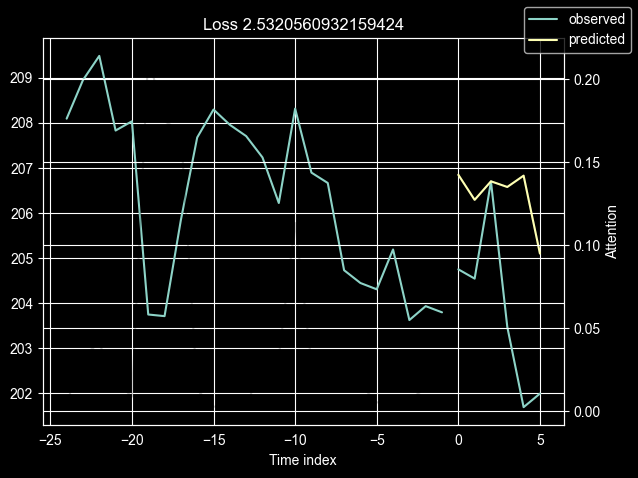

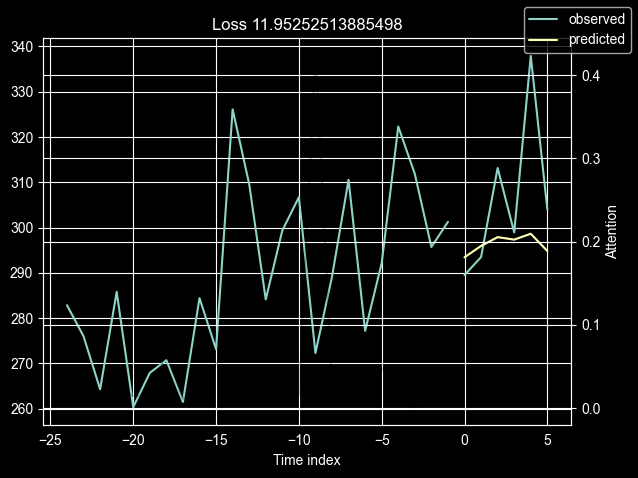

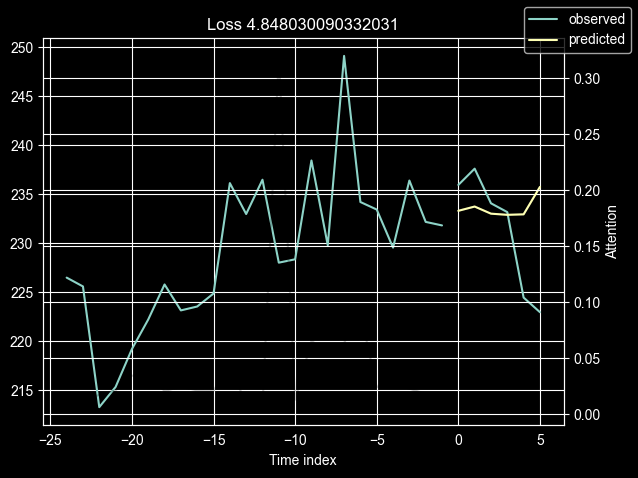

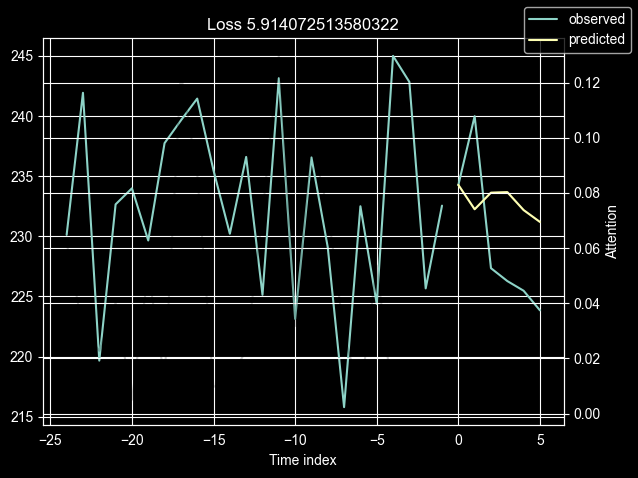

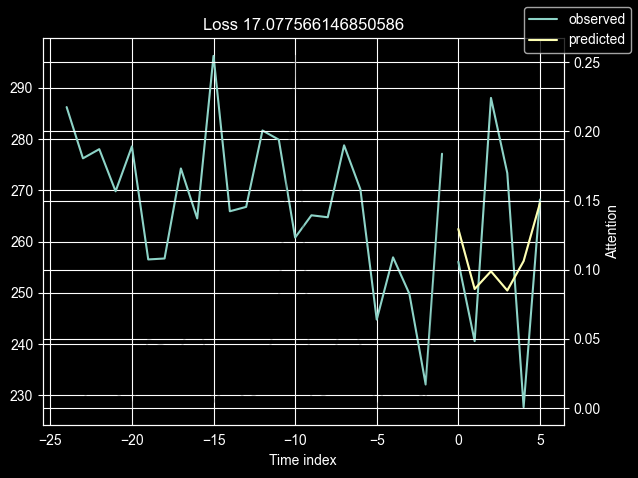

In [18]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.01,  # lower = more stable
    hidden_size=32,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=MAE(),
)

trainer = Trainer(
    max_epochs=30,
    accelerator="cpu",
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

raw_predictions = tft.predict(
    val_dataloader,
    mode="raw",
    return_x=True
)

n_samples = raw_predictions.output.prediction.shape[0]

for idx in range(min(n_samples, 5)):  # limit to 5 plots
    tft.plot_prediction(
        raw_predictions.x,
        raw_predictions.output,
        idx=idx,
        add_loss_to_title=True
    )
